In [6]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18
import glob
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist, sdss_rgb
from desi_lowz_funcs import find_objects_nearby
from construct_dwarf_galaxy_catalogs import process_sga_matches

%load_ext autoreload
%autoreload 2

sample_color_map = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }

import colorsys
import matplotlib.colors as mcolors


def related_contrast_color(hex_color, lighten=True, factor=0.4):
    # Convert HEX → RGB → HSV
    rgb = mcolors.to_rgb(hex_color)
    h, s, v = colorsys.rgb_to_hsv(*rgb)
    
    # Adjust brightness (v) or saturation
    if lighten:
        v = min(1, v + factor * (1 - v))
        s = max(0, s - 0.2)  # slightly desaturate
    else:
        v = max(0, v * (1 - factor))
        s = min(1, s + 0.2)
    
    # Back to HEX
    new_rgb = colorsys.hsv_to_rgb(h, s, v)
    return mcolors.to_hex(new_rgb)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
save_folder = "/global/homes/v/virajvm/galaxy_image_prior/paper_1/plots/"

### Mass Metallicity relationship!

In [8]:
from metallicity import get_metallicity_P16, get_metallicity_S22

In [9]:
from consolidate_photometry import consolidate_new_photo
from desi_lowz_funcs import get_stellar_mass_mia
from desi_lowz_funcs import match_fastspec_catalog
from consolidate_photometry import make_catalog_unmasked

fspec_save_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_fastspec_catalog/shreds_cat"

def get_fastspec_matched_catalog(gal_cat, save_name, match_method = "TARGETID"):
    '''
    Get the RA,DEC matched fastspec catalog and save it   
    '''

    #make sure the catalog being matched to us v2
    fastspec_cat = match_fastspec_catalog(gal_cat,coord_name = "",match_method = match_method)

    #make sure this is not a masked column!
    fastspec_cat = make_catalog_unmasked(fastspec_cat)

    # #save this 
    fastspec_cat.write(f"{fspec_save_path}/{save_name}",overwrite=True)

    #see what fraction of the catalog has np.nans in catalog
    mask = np.isnan(fastspec_cat["RA"])
    
    print(f"{np.sum(mask)}/{len(mask)} objects have no match in Fastspecfit catalog!")
    
    return fastspec_cat
    
def process_cat(sample, samp_type):
    bgsb_cat = Table.read(f"/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_{sample}_{samp_type}_catalog_w_aper_mags.fits")

    ## let us consolidate these objects!!
    bgsb_cat = consolidate_new_photo(bgsb_cat,sample=sample, add_pcnn=False)

    #with the finalized photometry, get the stellar masses!!
    gr_colors = bgsb_cat["MAG_G_BEST"].data - bgsb_cat["MAG_R_BEST"].data
    
    mstars_M24_new = get_stellar_mass_mia(gr_colors, bgsb_cat["MAG_G_BEST"].data , bgsb_cat["Z_CMB"].data, d_in_mpc = bgsb_cat["DIST_MPC_FIDU"].data, input_zred =  False)
    bgsb_cat["LOG_MSTAR_M24_NEW"] = mstars_M24_new

    gr_colors_old = bgsb_cat["MAG_G"].data - bgsb_cat["MAG_R"].data
    mstars_M24_old = get_stellar_mass_mia(gr_colors_old, bgsb_cat["MAG_G"].data , bgsb_cat["Z_CMB"].data, d_in_mpc = bgsb_cat["DIST_MPC_FIDU"].data, input_zred =  False)
    bgsb_cat["LOG_MSTAR_M24_OLD"] = mstars_M24_old

    #select only the subset that has shreds!
    bgsb_shred = bgsb_cat[(bgsb_cat["FRACFLUX_G"] > 0.2) & (bgsb_cat["FRACFLUX_R"] > 0.2) & (bgsb_cat["FRACFLUX_Z"] > 0.2) & (bgsb_cat["Z"] < 0.1)]

    bgsb_shred["RA_TARGET"] = bgsb_shred["RA"].copy()
    bgsb_shred["DEC_TARGET"] = bgsb_shred["DEC"].copy()

    #this is matching to v2.1
    if os.path.exists(fspec_save_path + f"/{sample}_cat.fits"):
        print("Reading existing fspec file")
        bgsb_shred_fspec = Table.read(fspec_save_path + f"/{sample}_cat.fits")
    else:
        print("Making new fspec file")
        bgsb_shred_fspec = get_fastspec_matched_catalog(bgsb_shred, f"{sample}_cat.fits", match_method = "TARGETID")

    ##get the nebular line fiagnostics
    oh_vals_s22, snr_mask = get_metallicity_S22(bgsb_shred_fspec)
    # oh_vals_p16, _ = get_metallicity_P16(bgsb_shred_fspec)

    #applyng the line SNR mask!
    bgsb_main_f =  bgsb_shred[snr_mask]

    ## return some quants:
    mstar_old = bgsb_main_f["LOG_MSTAR_M24_OLD"].data
    oh_w_old = oh_vals_s22

    good_mask = (bgsb_main_f["PHOTO_MASKBIT"].data == 0)
    mstar_new = bgsb_main_f["LOG_MSTAR_M24_NEW"].data[good_mask]
    oh_w_new = oh_vals_s22[good_mask]

    bgsb_good = bgsb_main_f[good_mask]
    
    # bgsb_good["O/H_P16"] = oh_w_new
    bgsb_good["O/H_S22"] = oh_w_new
    
    return mstar_old, oh_w_old, mstar_new, oh_w_new, bgsb_good


In [10]:
from consolidate_photometry import create_shred_maskbits_from_dict

def process_clean_cat():
    clean_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_clean_catalog_v4.fits")
    clean_cat = clean_cat[clean_cat["Z"] < 0.1]

    clean_maskbits = create_shred_maskbits_from_dict(clean_cat, bitmasks_to_apply = [7,12,13,14,15], verbose=True, mag_type = "")

    clean_cat = clean_cat[clean_maskbits == 0]
    
    #with the finalized photometry, get the stellar masses!!
    gr_colors = clean_cat["MAG_G"].data - clean_cat["MAG_R"].data
    
    mstars_M24_new = get_stellar_mass_mia(gr_colors, clean_cat["MAG_G"].data , clean_cat["Z_CMB"].data, d_in_mpc = clean_cat["DIST_MPC_FIDU"].data, input_zred =  False)
    clean_cat["LOG_MSTAR_M24"] = mstars_M24_new

    clean_cat["RA_TARGET"] = clean_cat["RA"].copy()
    clean_cat["DEC_TARGET"] = clean_cat["DEC"].copy()

    #this is matching to v2.1
    if os.path.exists(fspec_save_path + f"/clean_cat_cat.fits"):
        print("Reading existing fspec file")
        clean_cat_fspec = Table.read(fspec_save_path + f"/clean_cat_cat.fits")
    else:
        print("Making new fspec file")
        clean_cat_fspec = get_fastspec_matched_catalog(clean_cat, f"clean_cat_cat.fits", match_method = "TARGETID")

    ##get the nebular line fiagnostics
    oh_vals_s22, snr_mask = get_metallicity_S22(clean_cat_fspec)
    
    clean_cat_fspec = clean_cat_fspec[snr_mask]
    oh_vals_p16, _ = get_metallicity_P16(clean_cat_fspec)
    
    #applyng the line SNR mask!
    clean_cat_f =  clean_cat[snr_mask]

    clean_cat_f["O/H_S22"] = oh_vals_s22
    clean_cat_f["O/H_P16"] = oh_vals_p16

    return clean_cat_f, clean_cat_fspec


In [89]:
##read in the clean catalog and make the same plot
clean_cat, clean_cat_fspec = process_clean_cat()

MASKBIT=2^7, bad colors, fraction: 0.000008
MASKBIT=2^12, near sga outskirts, fraction: 0.004449
MASKBIT=2^13, bad rchisq, fraction: 0.000000
MASKBIT=2^14, low snr, fraction: 0.000999
MASKBIT=2^15, Tractor maskbit flagged: 0.0258
Reading existing fspec file
Satisyfing line snr+ratio mask = 0.21139137107354142


100%|██████████| 51240/51240 [01:27<00:00, 588.06it/s]


In [90]:
mstar_shred_bgsb, oh_shred_bgsb, mstar_new_bgsb, oh_new_bgsb, bgsb_new = process_cat("BGS_BRIGHT", "shreds")
mstar_shred_sga, oh_shred_sga, mstar_new_sga, oh_new_sga, sga_new = process_cat("SGA", "sga")
mstar_shred_bgsf, oh_shred_bgsf, mstar_new_bgsf, oh_new_bgsf, bgsf_new = process_cat("BGS_FAINT", "shreds")
mstar_shred_elg, oh_shred_elg, mstar_new_elg, oh_new_elg, elg_new = process_cat("ELG", "shreds")
mstar_shred_lowz, oh_shred_lowz, mstar_new_lowz, oh_new_lowz, lowz_new = process_cat("LOWZ", "shreds")

Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.23541726139499478
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0030
MASKBIT=2^1, cog not converge, fraction: 0.059616
MASKBIT=2^2, bad resid, fraction : 0.0056
MASKBIT=2^3, cog curve decrease, fraction: 0.0095
MASKBIT=2^4, aperfrac-in image, fraction: 0.000999
MASKBIT=2^5, aperfrac-mask image, fraction: 0.047055
MASKBIT=2^6, image-frac mask, fraction: 0.000809
MASKBIT=2^7, bad colors, fraction: 0.000333
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.102151
MASKBIT=2^10, aper-cen masked, fraction: 0.048958
MASKBIT=2^11, no seg found, fraction: 0.000048
MASKBIT=2^12, near sga outskirts, fraction: 0.013798
Fraction of sources where org trac is likely good = 0.23541726139499478
Updating the maskbits to reflect some objects reverted to original Tra

100%|██████████| 2968/2968 [00:04<00:00, 595.18it/s]


Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.2427291306398365
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0009
MASKBIT=2^1, cog not converge, fraction: 0.027983
MASKBIT=2^2, bad resid, fraction : 0.0016
MASKBIT=2^3, cog curve decrease, fraction: 0.0033
MASKBIT=2^4, aperfrac-in image, fraction: 0.005659
MASKBIT=2^5, aperfrac-mask image, fraction: 0.001729
MASKBIT=2^6, image-frac mask, fraction: 0.000314
MASKBIT=2^7, bad colors, fraction: 0.000629
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.022324
MASKBIT=2^10, aper-cen masked, fraction: 0.006446
MASKBIT=2^11, no seg found, fraction: 0.000000
Fraction of sources where org trac is likely good = 0.2427291306398365
Updating the maskbits to reflect some objects reverted to original Tractor photometry
MASKBIT=2^0, cog nan mask, 0.0009
MASKB

100%|██████████| 599/599 [00:01<00:00, 497.99it/s]


Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.31032412965186074
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0096
MASKBIT=2^1, cog not converge, fraction: 0.082233
MASKBIT=2^2, bad resid, fraction : 0.0114
MASKBIT=2^3, cog curve decrease, fraction: 0.0066
MASKBIT=2^4, aperfrac-in image, fraction: 0.000300
MASKBIT=2^5, aperfrac-mask image, fraction: 0.124850
MASKBIT=2^6, image-frac mask, fraction: 0.000900
MASKBIT=2^7, bad colors, fraction: 0.000600
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.110444
MASKBIT=2^10, aper-cen masked, fraction: 0.110144
MASKBIT=2^11, no seg found, fraction: 0.000300
MASKBIT=2^12, near sga outskirts, fraction: 0.006603
Fraction of sources where org trac is likely good = 0.31032412965186074
Updating the maskbits to reflect some objects reverted to original Tra

100%|██████████| 783/783 [00:01<00:00, 549.38it/s]


Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.19545918768167178
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.1824
MASKBIT=2^1, cog not converge, fraction: 0.033801
MASKBIT=2^2, bad resid, fraction : 0.0025
MASKBIT=2^3, cog curve decrease, fraction: 0.0014
MASKBIT=2^4, aperfrac-in image, fraction: 0.000314
MASKBIT=2^5, aperfrac-mask image, fraction: 0.195224
MASKBIT=2^6, image-frac mask, fraction: 0.001355
MASKBIT=2^7, bad colors, fraction: 0.001375
MASKBIT=2^8, source not on segment, fraction: 0.0041
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.045997
MASKBIT=2^10, aper-cen masked, fraction: 0.017224
MASKBIT=2^11, no seg found, fraction: 0.029991
MASKBIT=2^12, near sga outskirts, fraction: 0.005617
Fraction of sources where org trac is likely good = 0.19545918768167178
Updating the maskbits to reflect some objects reverted to original Tra

100%|██████████| 2522/2522 [00:04<00:00, 582.62it/s]


Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.5029171528588098
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0070
MASKBIT=2^1, cog not converge, fraction: 0.185531
MASKBIT=2^2, bad resid, fraction : 0.0023
MASKBIT=2^3, cog curve decrease, fraction: 0.0093
MASKBIT=2^4, aperfrac-in image, fraction: 0.000000
MASKBIT=2^5, aperfrac-mask image, fraction: 0.024504
MASKBIT=2^6, image-frac mask, fraction: 0.000000
MASKBIT=2^7, bad colors, fraction: 0.000000
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.099183
MASKBIT=2^10, aper-cen masked, fraction: 0.019837
MASKBIT=2^11, no seg found, fraction: 0.000000
MASKBIT=2^12, near sga outskirts, fraction: 0.002334
Fraction of sources where org trac is likely good = 0.5029171528588098
Updating the maskbits to reflect some objects reverted to original Tract

100%|██████████| 13/13 [00:00<00:00, 642.18it/s]


In [98]:
mstar_shred_all = np.concatenate([mstar_shred_bgsb, mstar_shred_bgsf, mstar_shred_sga, mstar_shred_elg, mstar_shred_lowz])
mstar_new_all = np.concatenate([mstar_new_bgsb, mstar_new_bgsf, mstar_new_sga, mstar_new_elg, mstar_new_lowz ])

oh_shred_all = np.concatenate([oh_shred_bgsb, oh_shred_bgsf, oh_shred_sga, oh_shred_elg, oh_shred_lowz])
oh_new_all = np.concatenate([oh_new_bgsb, oh_new_bgsf, oh_new_sga, oh_new_elg, oh_new_lowz])


In [99]:
from desi_lowz_funcs import get_contours

In [104]:
conts_shred = get_contours(mstar_shred_all, oh_shred_all, bins=np.arange(5.75,9.7,0.2),min_count=30,sigs=True)
conts_new = get_contours(mstar_new_all, oh_new_all, bins=np.arange(5.75,9.7,0.2),min_count=30,sigs=True)

conts_clean_s22 = get_contours(clean_cat["LOG_MSTAR_M24"].data, clean_cat["O/H_S22"], bins=np.arange(5.75,9.7,0.2),min_count=30,sigs=True)
# conts_clean_p16 = get_contours(clean_cat["LOG_MSTAR_M24"].data, clean_cat["O/H_P16"], bins=np.arange(5.75,9.7,0.2),min_count=20,sigs=True)


In [105]:
# import cmasher as cmr
# cmr_i = cmr.gothic_r.copy()
# cmr_i.set_under(alpha=0.)

def scholte22_rel(mstar):

    Z0=8.864
    gamma= 0.2439
    beta = 1.20
    m0 = 10**(10.49)

    return Z0 - (gamma/beta)*np.log10( 1 + (mstar/m0)**(-beta) )


In [106]:
# plt.figure(figsize = (4,4))
# plt.scatter(clean_cat["O/H_S22"], clean_cat["O/H_P16"],s=0.01  )
# plt.xlim([7,9])
# plt.xlabel("Pilyugin+2016")
# plt.xlabel("Schi+2016")
# plt.plot([7,9],[7,9],color = "k")
# plt.ylim([7,9])
# plt.show()

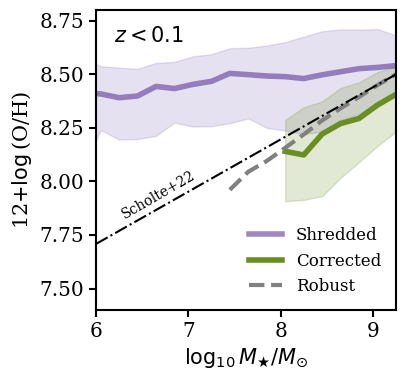

In [130]:
fig,ax = make_subplots(ncol = 1,nrow=1,return_fig=True)

# ax[0].hist2d(mstar_shred_all, oh_shred_all,range= ((6,9),(7,9)), bins=25,cmap=cmr_i,alpha=0.75 ) 
# ax[0].hist2d(mstar_new_all, oh_new_all,range= ((6,9),(7,9)), bins=25,cmap=cmr_i ,alpha=0.75 ) 

ax[0].plot(conts_shred["bin_cents"], conts_shred["median"],color = "#5D3A9B",lw=4,label = "Shredded",alpha=0.6)
ax[0].fill_between(x=conts_shred["bin_cents"], y1=conts_shred["sig1_high"], y2=conts_shred["sig1_low"], color = "#5D3A9B",alpha=0.15)

ax[0].plot(conts_new["bin_cents"], conts_new["median"],color = "olivedrab",lw=4,label = "Corrected")
ax[0].fill_between(x=conts_new["bin_cents"], y1=conts_new["sig1_high"], y2=conts_new["sig1_low"], color = "olivedrab",alpha=0.2)

ax[0].plot(conts_clean_s22["bin_cents"], conts_clean_s22["median"],color = "grey",ls="--",lw=3,label = "Robust")

mstar_grid = np.logspace(5.75,9.25,100)
oh_scholte22 = scholte22_rel(mstar_grid)
ax[0].plot(np.log10(mstar_grid)+0.25, oh_scholte22, color = "k",ls="-.",lw=1.5)

ax[0].text(6.25,7.825,"Scholte+22",rotation=30,fontsize = 10,color = "k")

for axi in ax:
    axi.set_xlim([6,9.25])
    axi.set_ylim([7.4,8.8])
    axi.set_ylabel(r"12+$\log$(O/H)",fontsize = 15)
    axi.set_xlabel(r"$\log_{10}M_{\bigstar}/M_{\odot}$",fontsize = 15)
    axi.legend(frameon=False,fontsize = 12,loc="lower right")

ax[0].text(6.2,8.65,r"$z < 0.1$",fontsize = 15,color="k")

plt.savefig(f"{save_folder}/mass_metal_shred.pdf",bbox_inches="tight")

plt.show()


## Size-mass relation!!

In [11]:
## compare SHAPE_R and 
from consolidate_photometry import consolidate_new_photo, consolidate_positions_and_shapes, get_stellar_mass_mia
from shred_photometry_maskbits import create_shred_maskbits_from_dict

def process_cat_size(sample, samp_type):
    bgsb_cat = Table.read(f"/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_{sample}_{samp_type}_catalog_w_aper_mags.fits")

    ## let us consolidate these objects!!
    bgsb_cat = consolidate_new_photo(bgsb_cat,sample=sample, add_pcnn=False)

    #with the finalized photometry, get the stellar masses!!
    gr_colors = bgsb_cat["MAG_G_BEST"].data - bgsb_cat["MAG_R_BEST"].data
    mstars_M24_new = get_stellar_mass_mia(gr_colors, bgsb_cat["MAG_G_BEST"].data , bgsb_cat["Z_CMB"].data, d_in_mpc = bgsb_cat["DIST_MPC_FIDU"].data, input_zred =  False)
    bgsb_cat["LOG_MSTAR_M24_NEW"] = mstars_M24_new

    gr_colors_old = bgsb_cat["MAG_G"].data - bgsb_cat["MAG_R"].data
    mstars_M24_old = get_stellar_mass_mia(gr_colors_old, bgsb_cat["MAG_G"].data , bgsb_cat["Z_CMB"].data, d_in_mpc = bgsb_cat["DIST_MPC_FIDU"].data, input_zred =  False)
    bgsb_cat["LOG_MSTAR_M24_OLD"] = mstars_M24_old

    #select only the subset that has shreds!
    bgsb_shred = bgsb_cat[(bgsb_cat["FRACFLUX_G"] > 0.2) & (bgsb_cat["FRACFLUX_R"] > 0.2) & (bgsb_cat["FRACFLUX_Z"] > 0.2) & (bgsb_cat["Z"] < 0.1)]

    ##get the old_sizes
    shape_r_old = bgsb_shred["SHAPE_R"].data
    #update this using the Z_CMB instead of heliocentric redshift
    r12_kpc_old = (Planck18.angular_diameter_distance(bgsb_shred["Z_CMB"] ).value) * 1000 * shape_r_old/206265
    mstar_old = bgsb_shred["LOG_MSTAR_M24_OLD"].data


    ##get the new sizes and shapes
    bgsb_new = bgsb_shred[bgsb_shred["PHOTO_MASKBIT"] == 0]
    bgsb_new = consolidate_positions_and_shapes(bgsb_new)
    shape_r_new = bgsb_new["R50_R"].data
    shape_r_new_old = bgsb_new["SHAPE_R"].data
    
    mstar_new = bgsb_new["LOG_MSTAR_M24_NEW"].data
    r12_kpc_new = (Planck18.angular_diameter_distance(bgsb_new["Z_CMB"] ).value) * 1000 * shape_r_new/206265
    r12_kpc_new_old = (Planck18.angular_diameter_distance(bgsb_new["Z_CMB"] ).value) * 1000 * shape_r_new_old/206265
    
    
    return mstar_old, r12_kpc_old, mstar_new, r12_kpc_new, r12_kpc_new_old, bgsb_new


In [12]:
mstar_shred_bgsb, size_shred_bgsb, mstar_new_bgsb, size_new_bgsb, size_new_old_bgsb, bgsb_new = process_cat_size("BGS_BRIGHT", "shreds")
mstar_shred_sga, size_shred_sga, mstar_new_sga, size_new_sga, _, sga_new = process_cat_size("SGA", "sga")
mstar_shred_bgsf, size_shred_bgsf, mstar_new_bgsf, size_new_bgsf, _, bgsf_new = process_cat_size("BGS_FAINT", "shreds")
mstar_shred_elg, size_shred_elg, mstar_new_elg, size_new_elg, _, elg_new = process_cat_size("ELG", "shreds")
mstar_shred_lowz, size_shred_lowz, mstar_new_lowz, size_new_lowz, _, lowz_new = process_cat_size("LOWZ", "shreds")




Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.23541726139499478
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0030
MASKBIT=2^1, cog not converge, fraction: 0.059616
MASKBIT=2^2, bad resid, fraction : 0.0056
MASKBIT=2^3, cog curve decrease, fraction: 0.0095
MASKBIT=2^4, aperfrac-in image, fraction: 0.000999
MASKBIT=2^5, aperfrac-mask image, fraction: 0.047055
MASKBIT=2^6, image-frac mask, fraction: 0.000809
MASKBIT=2^7, bad colors, fraction: 0.000333
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.102151
MASKBIT=2^10, aper-cen masked, fraction: 0.048958
MASKBIT=2^11, no seg found, fraction: 0.000048
MASKBIT=2^12, near sga outskirts, fraction: 0.013798
Fraction of sources where org trac is likely good = 0.23541726139499478
Updating the maskbits to reflect some objects reverted to original Tra

100%|██████████| 9644/9644 [00:00<00:00, 284876.28it/s]

Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column


Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.2427291306398365
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0009
MASKBIT=2^1, cog not converge, fraction: 0.027983
MASKBIT=2^2, bad resid, fraction : 0.0016
MASKBIT=2^3, cog curve decrease, fraction: 0.0033
MASKBIT=2^4, aperfrac-in image, fraction: 0.005659
MASKBIT=2^5, aperfrac-mask image, fraction: 0.001729
MASKBIT=2^6, image-frac mask, fraction: 0.000314
MASKBIT=2^7, bad colors, fraction: 0.000629
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.022324
MASKBIT=2^10, aper-cen masked, fraction: 0.006446
MASKBIT=2^11, no seg found, fraction: 0.000000
Fraction of sources where org trac is likely good = 0.2427291306398365
Updating the maskbits to reflect some objects reverted to original Tractor photometry
MASKBIT=2^0, cog nan mask, 0.0009
MASKB

100%|██████████| 1011/1011 [00:00<00:00, 280378.30it/s]

...

100%|██████████| 11597/11597 [00:00<00:00, 229910.97it/s]

Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column


Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.5029171528588098
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0070
MASKBIT=2^1, cog not converge, fraction: 0.185531
MASKBIT=2^2, bad resid, fraction : 0.0023
MASKBIT=2^3, cog curve decrease, fraction: 0.0093
MASKBIT=2^4, aperfrac-in image, fraction: 0.000000
MASKBIT=2^5, aperfrac-mask image, fraction: 0.024504
MASKBIT=2^6, image-frac mask, fraction: 0.000000
MASKBIT=2^7, bad colors, fraction: 0.000000
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.099183
MASKBIT=2^10, aper-cen masked, fraction: 0.019837
MASKBIT=2^11, no seg found, fraction: 0.000000
MASKBIT=2^12, near sga outskirts, fraction: 0.002334
Fraction of sources where org trac is likely good = 0.5029171528588098
Updating the maskbits to reflect some objects reverted to original Tract

100%|██████████| 188/188 [00:00<00:00, 141694.37it/s]

Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column


In [13]:
def process_cat_size_clean():
    clean_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_clean_catalog_v4.fits")
    print(len(clean_cat))
    clean_cat = clean_cat[(clean_cat["Z"] < 0.1)]

    clean_maskbits = create_shred_maskbits_from_dict(clean_cat, bitmasks_to_apply = [7,12,13,14,15], verbose=True, mag_type = "")

    clean_cat = clean_cat[clean_maskbits == 0]

    print(len(clean_cat))
    
    #with the finalized photometry, get the stellar masses!!
    gr_colors = clean_cat["MAG_G"].data - clean_cat["MAG_R"].data
    
    mstars_M24_new = get_stellar_mass_mia(gr_colors, clean_cat["MAG_G"].data , clean_cat["Z_CMB"].data, d_in_mpc = clean_cat["DIST_MPC_FIDU"].data, input_zred =  False)
    clean_cat["LOG_MSTAR_M24"] = mstars_M24_new

    clean_cat["RA_TARGET"] = clean_cat["RA"].copy()
    clean_cat["DEC_TARGET"] = clean_cat["DEC"].copy()

    ##get the size info
    shape_r_clean = clean_cat["SHAPE_R"].data
    #update this using the Z_CMB instead of heliocentric redshift
    r12_kpc_clean = (Planck18.angular_diameter_distance(clean_cat["Z_CMB"] ).value) * 1000 * shape_r_clean/206265
    mstar_clean = clean_cat["LOG_MSTAR_M24"].data

    return mstar_clean, r12_kpc_clean


In [14]:
mstar_clean_all, size_clean_all = process_cat_size_clean()

410379
MASKBIT=2^7, bad colors, fraction: 0.000008
MASKBIT=2^12, near sga outskirts, fraction: 0.004449
MASKBIT=2^13, bad rchisq, fraction: 0.000000
MASKBIT=2^14, low snr, fraction: 0.000999
MASKBIT=2^15, Tractor maskbit flagged: 0.0258
242394


In [15]:
mstar_shred_all = np.concatenate([mstar_shred_bgsb, mstar_shred_bgsf, mstar_shred_sga, mstar_shred_elg, mstar_shred_lowz])
mstar_new_all = np.concatenate([mstar_new_bgsb, mstar_new_bgsf, mstar_new_sga, mstar_new_elg, mstar_new_lowz ])

size_shred_all = np.concatenate([size_shred_bgsb, size_shred_bgsf, size_shred_sga, size_shred_elg, size_shred_lowz])
size_new_all = np.concatenate([size_new_bgsb, size_new_bgsf, size_new_sga, size_new_elg, size_new_lowz])



In [16]:
from desi_lowz_funcs import get_contours

In [17]:
conts_size_shred = get_contours(mstar_shred_all[size_shred_all > 0], np.log10(size_shred_all[size_shred_all > 0]), bins=np.arange(5.75,9.5,0.2),min_count=30,sigs=True)
conts_size_new = get_contours(mstar_new_all[size_new_all > 0], np.log10(size_new_all[size_new_all > 0]), bins=np.arange(5.75,9.5,0.2),min_count=30,sigs=True)


In [18]:
conts_size_clean = get_contours(mstar_clean_all[size_clean_all > 0], np.log10(size_clean_all[size_clean_all > 0]), bins=np.arange(5.75,9.5,0.2),min_count=30,sigs=True)



In [19]:
import matplotlib.ticker as mticker

## What fraction of sources have significant mag differences as function of their "true" size

In [46]:
temp = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_clean_catalog_v4.fits")


In [22]:
def process_cat(cat,sample):
    cat = consolidate_new_photo(cat, sample=sample, add_pcnn=False)
    cat = consolidate_positions_and_shapes(cat)
    cat = cat[cat["PHOTO_MASKBIT"] == 0]
    return cat

def get_deltas(sample_name):
    '''
    Need to combine across the clean sources as well.

    This returns the new shape_r, and the difference between size and photo for r-band
    '''

    temp = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_clean_catalog_v4.fits")
    tot_clean_count = len(temp[temp["SAMPLE"]==sample_name])
    print(f"SAMPLE clean count = {tot_clean_count}")

    cat_shred = Table.read(f"/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_{sample_name}_shreds_catalog_w_aper_mags.fits")
    cat_clean = Table.read(f"/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_{sample_name}_clean_catalog_w_aper_mags.fits")

    cat_sga = Table.read(f"/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_SGA_sga_catalog_w_aper_mags.fits")
    cat_sga = cat_sga[cat_sga["SAMPLE_DESI"] == sample_name]
    
    cat_shred = process_cat(cat_shred,sample_name)
    cat_clean = process_cat(cat_clean,sample_name)
    cat_sga = process_cat(cat_sga,"SGA")

    cat_shred = vstack([cat_shred,cat_sga])

    print(len(cat_shred), len(cat_clean), len(cat_sga))
    
    all_size_new = []
    all_size_deltas = []
    all_mag_r_deltas = []

    #get the sga + shred info
    mag_new_shred = cat_shred[f"MAG_R_BEST"].data
    mag_trac_shred = cat_shred[f"MAG_R"].data
    delta_mag_shred = mag_new_shred - mag_trac_shred

    size_new_shred = np.log10(cat_shred[f"R50_R"].data)
    size_trac_shred = np.log10(cat_shred[f"SHAPE_R"].data)
    delta_size_shred = size_new_shred - size_trac_shred

    #get the clean info so we can scale it
    mag_new_clean = cat_clean[f"MAG_R_BEST"].data
    mag_trac_clean = cat_clean[f"MAG_R"].data
    delta_mag_clean = mag_new_clean - mag_trac_clean

    size_new_clean = np.log10(cat_clean[f"R50_R"].data)
    size_trac_clean = np.log10(cat_clean[f"SHAPE_R"].data)
    delta_size_clean = size_new_clean - size_trac_clean

    #add the shred stuff
    all_mag_r_deltas.append(delta_mag_shred)
    all_size_deltas.append(delta_size_shred)
    all_size_new.append( size_new_shred )

    
    #add the clean stuff with the proper scaling!    
    clean_scale_factor = int(tot_clean_count/len(cat_clean))
    
    all_mag_r_deltas.append(list(delta_mag_clean) * clean_scale_factor )
    all_size_deltas.append(list(delta_size_clean) * clean_scale_factor )
    all_size_new.append(list(size_new_clean) * clean_scale_factor )

    all_size_new = np.concatenate(all_size_new)
    all_size_deltas = np.concatenate(all_size_deltas)
    all_mag_deltas = np.concatenate(all_mag_r_deltas)
    
    return all_size_new[~np.isnan(all_size_deltas)], all_size_deltas[~np.isnan(all_size_deltas)], all_mag_deltas[~np.isnan(all_size_deltas)]


In [23]:
# all_cats = [bgsb_new] #, sga_new, bgsf_new, elg_new, lowz_new]
all_cats = [bgsb_new, sga_new, bgsf_new, elg_new, lowz_new]



In [24]:
all_size_diffs = []
all_mstar_diffs = []
all_mag_diffs = []
all_size_new = []

for cati in all_cats:
    cati = cati[cati["SHAPE_R"].data > 0]
    print(len(cati))
    all_size_new.append( np.log10(cati["R50_R"].data)  )
    all_size_diffs.append( np.log10(cati["R50_R"].data) - np.log10(cati["SHAPE_R"].data) )
    all_mstar_diffs.append( cati["LOG_MSTAR_M24_NEW"].data -  cati["LOG_MSTAR_M24_OLD"].data )
    all_mag_diffs.append( cati["MAG_R_BEST"].data -  cati["MAG_R"].data )
    
all_size_diffs = np.concatenate(all_size_diffs)
all_size_new = np.concatenate(all_size_new)
all_mstar_diffs = np.concatenate(all_mstar_diffs)
all_mag_diffs = np.concatenate(all_mag_diffs)


9626
931
1844
9015
188


In [50]:
size_new_bgsb, size_delta_bgsb, mag_delta_bgsb = get_deltas("BGS_BRIGHT")
size_new_bgsf, size_delta_bgsf, mag_delta_bgsf = get_deltas("BGS_FAINT")

size_new_lowz, size_delta_lowz, mag_delta_lowz = get_deltas("LOWZ")
size_new_elg, size_delta_elg, mag_delta_elg = get_deltas("ELG")



SAMPLE clean count = 157282
Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.23541726139499478
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0030
MASKBIT=2^1, cog not converge, fraction: 0.059616
MASKBIT=2^2, bad resid, fraction : 0.0056
MASKBIT=2^3, cog curve decrease, fraction: 0.0095
MASKBIT=2^4, aperfrac-in image, fraction: 0.000999
MASKBIT=2^5, aperfrac-mask image, fraction: 0.047055
MASKBIT=2^6, image-frac mask, fraction: 0.000809
MASKBIT=2^7, bad colors, fraction: 0.000333
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.102151
MASKBIT=2^10, aper-cen masked, fraction: 0.048958
MASKBIT=2^11, no seg found, fraction: 0.000048
MASKBIT=2^12, near sga outskirts, fraction: 0.013798
Fraction of sources where org trac is likely good = 0.23541726139499478
Updating the maskbits to reflect some obje

100%|██████████| 21018/21018 [00:00<00:00, 285775.96it/s]

Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column


Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.35179735127180994
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0001
MASKBIT=2^1, cog not converge, fraction: 0.018394
MASKBIT=2^2, bad resid, fraction : 0.0001
MASKBIT=2^3, cog curve decrease, fraction: 0.0001
MASKBIT=2^4, aperfrac-in image, fraction: 0.000000
MASKBIT=2^5, aperfrac-mask image, fraction: 0.002207
MASKBIT=2^6, image-frac mask, fraction: 0.001051
MASKBIT=2^7, bad colors, fraction: 0.000000
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.029220
MASKBIT=2^10, aper-cen masked, fraction: 0.000946
MASKBIT=2^11, no seg found, fraction: 0.000000
MASKBIT=2^12, near sga outskirts, fraction: 0.005361
Fraction of sources where org trac is likely good = 0.35179735127180994
Updating the maskbits to reflect some objects reverted to original Tra

100%|██████████| 9514/9514 [00:00<00:00, 238299.07it/s]


...

100%|██████████| 9994/9994 [00:00<00:00, 285549.94it/s]


Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column
Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: nan
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, nan
MASKBIT=2^1, cog not converge, fraction:  nan
MASKBIT=2^2, bad resid, fraction : nan
MASKBIT=2^3, cog curve decrease, fraction: nan
MASKBIT=2^4, aperfrac-in image, fraction:  nan
MASKBIT=2^5, aperfrac-mask image, fraction:  nan
MASKBIT=2^6, image-frac mask, fraction:  nan
MASKBIT=2^7, bad colors, fraction:  nan
MASKBIT=2^8, source not on segment, fraction: nan
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction:  nan
MASKBIT=2^10, aper-cen masked, fraction:  nan
MASKBIT=2^11, no seg found, fraction:  nan
Fraction of sources where org trac is likely good = nan
Updating the maskbits to reflect some objects reverted to original Tractor photometry
MASKBIT=2^0, cog nan mask, 

0it [00:00, ?it/s]
0it [00:00, ?it/s]

Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column


39253 1104 0


In [51]:
def get_sample_fracs(all_size_new, all_size_diffs, cut = 0.3 ):
    
    bins =  np.arange(0.15, 2, 0.1)

    # mask_size = np.abs(all_size_diffs) > cut
    mask_size = np.abs(all_size_diffs) > cut
    

    bin_centers = 0.5*(bins[:-1] + bins[1:])

    fracs = []
    
    for i in range(len(bins)-1):
        in_bin = (all_size_new > bins[i]) & (all_size_new <= bins[i+1])
        if in_bin.sum() < 100:
            fracs.append(np.nan)
        else:
            fracs.append(mask_size[in_bin].mean())

    return np.array(bin_centers), fracs



In [52]:
bin_cens, bgsb_size_fracs = get_sample_fracs(size_new_bgsb, size_delta_bgsb,cut=0.3)
bin_cens, bgsb_mag_fracs = get_sample_fracs(size_new_bgsb, mag_delta_bgsb,cut=0.75)

bin_cens, bgsf_size_fracs = get_sample_fracs(size_new_bgsf, size_delta_bgsf,cut=0.3)
bin_cens, bgsf_mag_fracs = get_sample_fracs(size_new_bgsf, mag_delta_bgsf,cut=0.75)

bin_cens, lowz_size_fracs = get_sample_fracs(size_new_lowz, size_delta_lowz,cut=0.3)
bin_cens, lowz_mag_fracs = get_sample_fracs(size_new_lowz, mag_delta_lowz,cut=0.75)

bin_cens, elg_size_fracs = get_sample_fracs(size_new_elg, size_delta_elg,cut=0.3)
bin_cens, elg_mag_fracs = get_sample_fracs(size_new_elg, mag_delta_elg,cut=0.75)


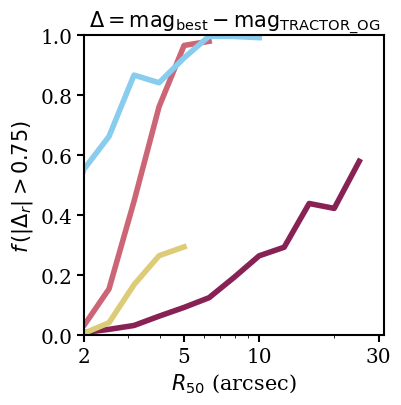

In [53]:
sample_color_map = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }

lw = 4

ax = make_subplots(ncol=1,nrow=1,row_spacing=0.5)

# ax[0].plot(10**bin_cens, bgsb_size_fracs, color = sample_color_map["BGS_BRIGHT"],lw=lw)
# ax[0].plot(10**bin_cens, bgsf_size_fracs, color = sample_color_map["BGS_FAINT"],lw=lw)
# ax[0].plot(10**bin_cens, lowz_size_fracs, color = sample_color_map["LOWZ"],lw=lw)
# ax[0].plot(10**bin_cens, elg_size_fracs, color = sample_color_map["ELG"],lw=lw)

ax[0].plot(10**bin_cens, bgsb_mag_fracs, color = sample_color_map["BGS_BRIGHT"],lw=lw)
ax[0].plot(10**bin_cens, bgsf_mag_fracs, color = sample_color_map["BGS_FAINT"],lw=lw)
ax[0].plot(10**bin_cens, lowz_mag_fracs, color = sample_color_map["LOWZ"],lw=lw)
ax[0].plot(10**bin_cens, elg_mag_fracs, color = sample_color_map["ELG"],lw=lw)

for i in range(1):
    ax[i].set_xlim([10**0.4,10**1.5])
    ax[i].set_xscale("log")
    ax[i].set_ylim([0,1])

     # Keep auto major ticks
    ax[i].xaxis.set_major_locator(plt.LogLocator(base=10))  
    ax[i].xaxis.set_minor_locator(plt.LogLocator(base=10, subs='auto'))

    # ADD additional reference ticks at 5, 10, 30
    ax[i].set_xticks([2,5, 10, 30], minor=False)
    
    # Label them
    ax[i].set_xticklabels(["2","5", "10", "30"])


ax[0].set_title(r"$\Delta = \text{mag}_{\rm best} - \text{mag}_{\rm TRACTOR\_OG }$",fontsize = 15)
ax[0].set_ylabel(r"$f\,(|\Delta_r| > 0.75)$",fontsize=15)

ax[0].set_xlabel("$R_{50}$ (arcsec)",fontsize=15)

# plt.savefig(f"{save_folder}/signi_mag_frac_size_true.png",bbox_inches="tight")

plt.show()



In [20]:
import cmasher as cmr
cmr_i = cmr.gothic_r.copy()
cmr_i.set_under(alpha=0.)

from desi_lowz_funcs import make_alternating_plot

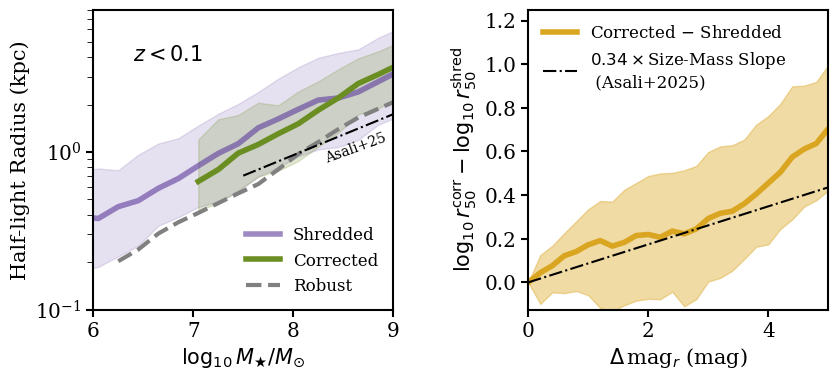

In [30]:
ax = make_subplots(ncol=2,nrow=1,col_spacing = 1.35)

#####

ax[0].plot(conts_size_shred["bin_cents"], 10**np.array(conts_size_shred["median"]),color = "#5D3A9B",lw=4,label = "Shredded",alpha=0.6)
ax[0].fill_between(x=conts_size_shred["bin_cents"], y1=10**np.array(conts_size_shred["sig1_high"]), y2=10**np.array(conts_size_shred["sig1_low"]), color = "#5D3A9B",alpha=0.15)

ax[0].plot(conts_size_new["bin_cents"], 10**np.array(conts_size_new["median"]),color = "olivedrab",lw=4,label = "Corrected")
ax[0].fill_between(x=conts_size_new["bin_cents"], y1=10**np.array(conts_size_new["sig1_high"]), y2=10**np.array(conts_size_new["sig1_low"]), color = "olivedrab",alpha=0.2)

ax[0].plot(conts_size_clean["bin_cents"], 10**np.array(conts_size_clean["median"]),color = "grey",ls="--",label = "Robust",lw=3)

mstar_grid = np.linspace(7.5,9.5)
log_r12_model = 0.26*mstar_grid - 2.10
ax[0].plot(mstar_grid, 10**log_r12_model, color = "k",ls="-.",lw=1.5)
ax[0].text(8.3,10**-0.065,"Asali+25",rotation=20,fontsize = 10,color = "k")

ax[0].set_xlim([6,9])
ax[0].set_ylim([0.1,8])
ax[0].set_ylabel(r"Half-light Radius (kpc)",fontsize = 15)
ax[0].set_xlabel(r"$\log_{10}M_{\bigstar}/M_{\odot}$",fontsize = 15)
ax[0].legend(frameon=False,fontsize = 12,loc="lower right")
ax[0].set_yscale("log")

# # Turn on the minor tick marks (but no labels)
ax[0].tick_params(axis="y", which="minor", length=4)

ax[0].text(0.25,0.85,r"$z < 0.1$",fontsize = 15,color="k",transform=ax[0].transAxes,ha="center", va="center")


##################

x = -1*all_mag_diffs
y = all_size_diffs

conts_diff = get_contours(x,y,bins=np.arange(-0.1,5.5,0.2), sigs=True)

color = "goldenrod"
ax[1].plot(conts_diff["bin_cents"], conts_diff["median"],color = color,lw=4,label = r"Corrected $-$ Shredded")
ax[1].fill_between(x=conts_diff["bin_cents"], y1=conts_diff["sig1_high"], y2=conts_diff["sig1_low"], color = color,alpha=0.4)

xgrid = np.linspace(0,5,100)
ax[1].plot(xgrid,0.335*0.26*xgrid,color = "k",ls="-.",lw=1.5,label = r"$0.34\times$" "Size-Mass Slope \n (Asali+2025)")

ax[1].legend(frameon=False,fontsize=12,loc="upper left")
ax[1].set_xlim([0,5])
ax[1].set_ylim([-0.125,1.25])
ax[1].set_xlabel(r"$\Delta\,$mag$_r$ (mag)",fontsize = 15)
ax[1].set_ylabel(r"$\log_{10}r^{\rm corr}_{50} - \log_{10}r^{\rm shred}_{50} $",fontsize = 15)

plt.savefig(f"{save_folder}/shred_size_mass_plot.pdf",bbox_inches="tight")

plt.show()

## Galaxy Number Counts!

Do this for BGS Bright and then total?

In [11]:
from desi_lowz_funcs import save_table, get_useful_cat_colms, _n_or_more_gt, _n_or_more_lt, get_remove_flag
from easyquery import Query, QueryMaker
reduce_compare = QueryMaker.reduce_compare

def process_cat_counts(sample, samp_type):
    #read the clean_cat
    clean_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_clean_catalog_v4.fits")
    clean_cat = clean_cat[clean_cat["SAMPLE"] == sample]
    
    clean_cat["MAG_G_BEST"] = clean_cat["MAG_G"].copy()
    clean_cat["MAG_R_BEST"] = clean_cat["MAG_R"].copy()
    clean_cat["MAG_Z_BEST"] = clean_cat["MAG_Z"].copy()
    clean_cat["PHOTO_MASKBIT"] = np.zeros(len(clean_cat))
    clean_cat = clean_cat["Z","MAG_G","MAG_R","MAG_Z",  "MAG_G_BEST", "MAG_R_BEST", "MAG_Z_BEST", "FRACFLUX_G", "FRACFLUX_R", "FRACFLUX_Z", "PHOTO_MASKBIT", "Z_CMB", "DIST_MPC_FIDU"]
    
    #read the shred_cat
    bgsb_cat = Table.read(f"/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_{sample}_{samp_type}_catalog_w_aper_mags.fits")
    ## let us consolidate these objects!!
    bgsb_cat = consolidate_new_photo(bgsb_cat,sample=sample, add_pcnn=False)

    bgsb_cat = bgsb_cat["Z","MAG_G","MAG_R","MAG_Z","MAG_G_BEST","MAG_R_BEST","MAG_Z_BEST", "FRACFLUX_G","FRACFLUX_R", "FRACFLUX_Z","PHOTO_MASKBIT", "Z_CMB", "DIST_MPC_FIDU"]

    #read the sga cat
    sga_cat = Table.read(f"/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_photometry/iron_SGA_sga_catalog_w_aper_mags.fits")
    sga_cat = consolidate_new_photo(sga_cat,sample="SGA", add_pcnn=False)

    print(len(sga_cat))
    sga_cat = sga_cat[sga_cat["SAMPLE_DESI"] == sample]["Z","MAG_G","MAG_R","MAG_Z","MAG_G_BEST","MAG_R_BEST","MAG_Z_BEST", "FRACFLUX_G","FRACFLUX_R", "FRACFLUX_Z","PHOTO_MASKBIT", "Z_CMB", "DIST_MPC_FIDU"]
    print(len(sga_cat))
    ##stack these all now!!
    tot_cat = vstack([clean_cat, bgsb_cat, sga_cat])

    gr_colors = tot_cat["MAG_G"].data - tot_cat["MAG_R"].data
    mstars_M24_old = get_stellar_mass_mia(gr_colors, tot_cat["MAG_G"].data , tot_cat["Z_CMB"].data, d_in_mpc = tot_cat["DIST_MPC_FIDU"].data, input_zred =  False)
    tot_cat["LOG_M24_OLD"] = mstars_M24_old

    gr_colors = tot_cat["MAG_G_BEST"].data - tot_cat["MAG_R_BEST"].data
    mstars_M24_new = get_stellar_mass_mia(gr_colors, tot_cat["MAG_G_BEST"].data , tot_cat["Z_CMB"].data, d_in_mpc = tot_cat["DIST_MPC_FIDU"].data, input_zred =  False)
    tot_cat["LOG_M24_NEW"] = mstars_M24_new

    ##get the fracflux cut!!

    #identifying objects with large fracflux
    fracflux_grz = [f"FRACFLUX_{b}" for b in "GRZ"]
    shred_queries = [Query(_n_or_more_lt(fracflux_grz, 2, 0.2)) ]
    # note that the this is n_or_more_LT!! so be careful about that!
    #these are masks for objects that did not satisfy the above condition!
    shred_mask = (get_remove_flag(tot_cat, shred_queries) == 0)
    
    return tot_cat, shred_mask


In [12]:

bgsb_tot_cat, bgsb_shred_mask = process_cat_counts("BGS_BRIGHT", "shreds")


Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.23541726139499478
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0030
MASKBIT=2^1, cog not converge, fraction: 0.059616
MASKBIT=2^2, bad resid, fraction : 0.0056
MASKBIT=2^3, cog curve decrease, fraction: 0.0095
MASKBIT=2^4, aperfrac-in image, fraction: 0.000999
MASKBIT=2^5, aperfrac-mask image, fraction: 0.047055
MASKBIT=2^6, image-frac mask, fraction: 0.000809
MASKBIT=2^7, bad colors, fraction: 0.000333
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.102151
MASKBIT=2^10, aper-cen masked, fraction: 0.048958
MASKBIT=2^11, no seg found, fraction: 0.000048
MASKBIT=2^12, near sga outskirts, fraction: 0.013798
Fraction of sources where org trac is likely good = 0.23541726139499478
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect som

In [13]:
len(bgsb_tot_cat)

184511

In [14]:
bgsb_clean = bgsb_tot_cat[~bgsb_shred_mask]

In [16]:
np.sum(bgsb_shred_mask)

14724

In [17]:
len(bgsb_clean), len(bgsb_tot_cat)

(169787, 184511)

In [18]:
mstars_ff_cut = bgsb_clean["LOG_M24_OLD"].data

mstars_tot = bgsb_tot_cat["LOG_M24_OLD"].data

mstars_tot_f = np.concatenate([ mstars_ff_cut, bgsb_tot_cat[bgsb_shred_mask & (bgsb_tot_cat["PHOTO_MASKBIT"] ==0) ]["LOG_M24_NEW"].data ])



In [19]:
bins = np.arange(5.75, 9.5, 0.25)   # edges: 6.0, 6.25, ..., 9.0
bin_cens = 0.5*(bins[1:] + bins[:-1])

ff_counts,_ = np.histogram(mstars_ff_cut, bins=bins)
tot_counts,_ = np.histogram(mstars_tot, bins=bins)
tot_counts_f,_ = np.histogram(mstars_tot_f, bins=bins)



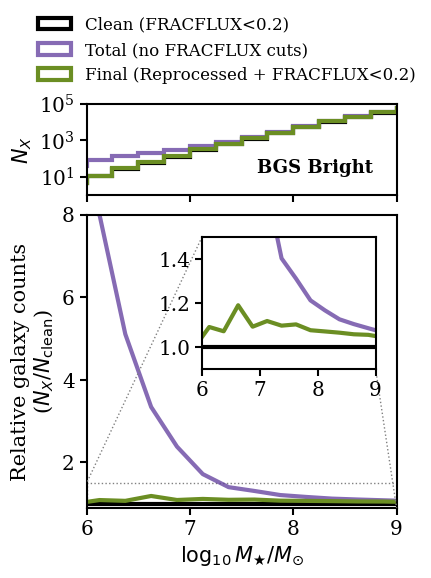

In [33]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, (ax_hist, ax_main) = plt.subplots(
    2, 1, figsize=(4,5.25),
    sharex=True,
    gridspec_kw={"height_ratios": [1.25, 4], "hspace": 0.1}
)

# ------------------------ Histogram panel ------------------------
ax_hist.hist(mstars_ff_cut, bins=np.arange(5.75,9.5,0.25), histtype="step", 
             color="k", lw=3, label="Clean (FRACFLUX<0.2)")
ax_hist.hist(mstars_tot, bins=np.arange(5.75,9.5,0.25), histtype="step", 
             color="#5D3A9B", lw=3, label="Total (no FRACFLUX cuts)",alpha=0.75)
ax_hist.hist(mstars_tot_f, bins=np.arange(5.75,9.5,0.25), histtype="step", 
             color="olivedrab", lw=3, label="Final (Reprocessed + FRACFLUX<0.2)")

ax_hist.set_ylabel("$N_X$", fontsize=15)
# ax_hist.legend(fontsize=10,ncol=2)
ax_hist.set_yscale("log")
ax_hist.set_ylim([1,1e5])
ax_hist.set_yticks([1e1,1e3,1e5])

fig.legend(
    handles=ax_hist.get_lines(),                 # all line objects
    labels=[l.get_label() for l in ax_hist.get_lines()],
    loc="upper center",
    bbox_to_anchor=(0.475, 1.075),                 # centered above the figure
    ncol=1,
    frameon=False,
    fontsize=12
)

# ------------------------ Main panel ------------------------
ax_main.plot(bin_cens, ff_counts/ff_counts, color="k", lw=3)
ax_main.plot(bin_cens, tot_counts/ff_counts, color="#5D3A9B", lw=3, alpha=0.75)
ax_main.plot(bin_cens, tot_counts_f/ff_counts, color="olivedrab", lw=3)

ax_main.set_xlim([6,9])
ax_main.set_ylim([0.9,8])
ax_main.set_ylabel("Relative galaxy counts\n" r"($N_X/N_{\mathrm{clean}}$)", fontsize=15)
ax_main.set_xlabel(r"$\log_{10}M_{\bigstar}/M_{\odot}$", fontsize=15)

# ------------------------ Inset ------------------------
ax_inset = inset_axes(ax_main, width="140%", height="150%",
                      bbox_to_anchor=(0.35, 0.45, 0.4, 0.3),
                      bbox_transform=ax_main.transAxes,
                      loc='lower left')

ax_inset.plot(bin_cens, ff_counts/ff_counts, color="k",lw=3)
ax_inset.plot(bin_cens, tot_counts/ff_counts, color="#5D3A9B", lw=3, alpha=0.75)
ax_inset.plot(bin_cens, tot_counts_f/ff_counts, color="olivedrab", lw=3)

ax_inset.set_xlim([6,9])
ax_inset.set_ylim([0.9,1.5])
ax_inset.set_xticks([6,7,8,9])

# Add zoom indicator
mark_inset(ax_main, ax_inset, loc1=2, loc2=4, fc="none", ec="0.5",ls="dotted")

ax_hist.text(0.55,0.3,r"BGS Bright",fontsize=13,transform=ax_hist.transAxes,weight="bold",va="center")

plt.savefig(f"{save_folder}/ncounts_relative_shred.pdf",bbox_inches="tight")

plt.show()


In [ ]:
1+1